### Logistic Regression

- 모델의 이름은 회귀, 결과는 분류 형태
- 0과 1 사이의 값(실수)을 예측하여 0.5보다 큰 경우 1 출력 작은 경우는 0 출력
- 종속 변수가 범주형인 경우 적용하는 회귀 분석 방식
- 종속 변수 y를 직접 모델링하지 않고 y가 특정 범주에 속하는 확률을 모델링

- parameter
    - `penalty`
        - 기본값 : `l2`
        - `l1` : Lasso
        - `l2` : Ridge
        - `elasticnet` : ElasticNet
        - None : 규제 없음 (선형 회귀)
    - `C`
        - 기본값 : 1.0
        - 규제 강도의 역수
            - 작을 수록 규제 강도 up (과적합 방지)
            - 클 수록 규제 강도 down (유연)
    - `class_weight`
        - 기본값 : None
        - 클래스의 불균형을 처리
            - `balanced` : 클래스의 빈도에 반비례하게 가중치를 부여
            - dict형 데이터 : {클래스명: 가중치, ... } → 특정 클래스에 가중치를 선택하여 부여
    - `solver`
        - 기본값 : `lbfgs`
        - 최적의 알고리즘 선택 (데이터의 크기, 규제 방식)
            - `lbfgs` : 다중 클래스일 때, 빠르고 안정적. L2/None 지원
            - `liblinear` : 데이터가 적을 때, L1/L2 지원
            - `saga` : 대규모 데이터일 때, L1/L2/ElasticNet 지원
    - `multi_class`
        - 기본값 : `auto`
        - 다중 클래스의 처리 방식
            - `ovr` (One vs Rest) : 이진분류를 반복 작업
            - `multinomial` : softmax 기반, solver 제한
            - `auto` : solver와 데이터의 크기를 기반으로 자동 설정
    - `l1_ratio`
        - 기본값 : None
        - ElasticNet에서만 사용 가능
    - `dual`
        - 기본값 : False
        - solver의 값이 `liblinear`인 경우 사용
        - 데이터의 개수가 적은 경우 사용
        - 쌍대문제를 생성하여 해답을 내는 과정을 사용할 것인가?


- 속성
    - `coef_`
        - 회귀 계수 출력
    - `intercept_`
        - y절편 출력
    - `classes_`
        - 학습된 클래스의 목록

- 메서드
    - `decision_function(x)`
        - 클래스별 점수
    - `predict_proba(x)`
        - 클래스별 예측 확률
    - `predict_log_proba(x)`
        - 클래스별 예측 로그 확률
    - `score(x, y)`
        - 회귀 모델은 score()의 결과가 r2score로 나오지만 logistic은 accuracy를 출력

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

In [2]:
# 경고 메세지 출력을 필터
warnings.filterwarnings('ignore')

In [3]:
body = pd.read_csv('../data/bodyPerformance.csv')
body.head()

,age,gender,height_cm,weight_kg,body fat_%,diastolic,systolic,gripForce,sit and bend forward_cm,sit-ups counts,broad jump_cm,class
0,27.0,M,172.3,75.24,21.3,80.0,130.0,54.9,18.4,60.0,217.0,C
1,25.0,M,165.0,55.80,15.7,77.0,126.0,36.4,16.3,53.0,229.0,A
2,31.0,M,179.6,78.00,20.1,92.0,152.0,44.8,12.0,49.0,181.0,C
3,32.0,M,174.5,71.10,18.4,76.0,147.0,41.4,15.2,53.0,219.0,B
4,28.0,M,173.8,67.70,17.1,70.0,127.0,43.5,27.1,45.0,217.0,B


In [4]:
body.info()

<class 'pandas.DataFrame'>
RangeIndex: 13393 entries, 0 to 13392
Data columns (total 12 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   age                      13393 non-null  float64
 1   gender                   13393 non-null  str    
 2   height_cm                13393 non-null  float64
 3   weight_kg                13393 non-null  float64
 4   body fat_%               13393 non-null  float64
 5   diastolic                13393 non-null  float64
 6   systolic                 13393 non-null  float64
 7   gripForce                13393 non-null  float64
 8   sit and bend forward_cm  13393 non-null  float64
 9   sit-ups counts           13393 non-null  float64
 10  broad jump_cm            13393 non-null  float64
 11  class                    13393 non-null  str    
dtypes: float64(10), str(2)
memory usage: 1.2 MB


In [7]:
body.describe()

,age,height_cm,weight_kg,body fat_%,diastolic,systolic,gripForce,sit and bend forward_cm,sit-ups counts,broad jump_cm
count,13393.000000,13393.000000,13393.000000,13393.000000,13393.000000,13393.000000,13393.000000,13393.000000,13393.000000,13393.000000
mean,36.775106,168.559807,67.447316,23.240165,78.796842,130.234817,36.963877,15.209268,39.771224,190.129627
std,13.625639,8.426583,11.949666,7.256844,10.742033,14.713954,10.624864,8.456677,14.276698,39.868000
min,21.000000,125.000000,26.300000,3.000000,0.000000,0.000000,0.000000,-25.000000,0.000000,0.000000
25%,25.000000,162.400000,58.200000,18.000000,71.000000,120.000000,27.500000,10.900000,30.000000,162.000000
50%,32.000000,169.200000,67.400000,22.800000,79.000000,130.000000,37.900000,16.200000,41.000000,193.000000
75%,48.000000,174.800000,75.300000,28.000000,86.000000,141.000000,45.200000,20.700000,50.000000,221.000000
max,64.000000,193.800000,138.100000,78.400000,156.200000,201.000000,70.500000,213.000000,80.000000,303.000000


In [8]:
# gender column 문자들을 숫자 형태로 변환

body['gender'].value_counts()

gender
M    8467
F    4926
Name: count, dtype: int64

In [ ]:
# map 활용
# body['gender'].map(
#     lambda x : 0 if x == 'M' else 1
# )

# map 활용2
# body['gender'].map(
#     {
#         'M': 0,
#         'F': 1
#     }
# )

# replace 활용
# body['gender'].replace('M', 0).replace('F', 1)

In [11]:
# dummies

df = pd.get_dummies(body, columns = ['gender'], drop_first = True)

In [ ]:
# numpy

np.where(body['gender'] == 'M', 0, 1)
# np.where(조건식, 참인 경우 결과, 거짓인 경우 결과)

In [12]:
# class에서 A는 1 그 외의 값들은 0으로 변환

df['class_1'] = np.where( df['class'] == 'A', 1, 0 )

In [13]:
df['class_1'].value_counts()

class_1
0    10045
1     3348
Name: count, dtype: int64

In [20]:
q_1, q_3 = np.percentile(df['sit and bend forward_cm'], [0.25, 0.75])
IQR = q_3 - q_1
upper_whis = q_3 + 1.5*IQR
lower_whis = q_1 - 1.5*IQR

upper_flag = df['sit and bend forward_cm'] > upper_whis
lower_flag = df['sit and bend forward_cm'] < lower_whis

df.loc[upper_flag|lower_flag, ]

,age,height_cm,weight_kg,body fat_%,diastolic,systolic,gripForce,sit and bend forward_cm,sit-ups counts,broad jump_cm,class,gender_M,class_1
0,27.0,172.3,75.24,21.3,80.0,130.0,54.9,18.4,60.0,217.0,C,True,0
1,25.0,165.0,55.80,15.7,77.0,126.0,36.4,16.3,53.0,229.0,A,True,1
2,31.0,179.6,78.00,20.1,92.0,152.0,44.8,12.0,49.0,181.0,C,True,0
3,32.0,174.5,71.10,18.4,76.0,147.0,41.4,15.2,53.0,219.0,B,True,0
4,28.0,173.8,67.70,17.1,70.0,127.0,43.5,27.1,45.0,217.0,B,True,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
13388,25.0,172.1,71.80,16.2,74.0,141.0,35.8,17.4,47.0,198.0,C,True,0
13389,21.0,179.7,63.90,12.1,74.0,128.0,33.0,1.1,48.0,167.0,D,True,0
13390,39.0,177.2,80.50,20.1,78.0,132.0,63.5,16.4,45.0,229.0,A,True,1
13391,64.0,146.1,57.70,40.4,68.0,121.0,19.3,9.2,0.0,75.0,D,False,0


In [32]:
# 독립 변수 종속 변수 데이터 분할

X = df.drop(['class', 'class_1'], axis=1)
y = df['class_1']

In [33]:
# train test 데이터 분할

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.3, random_state = 42, stratify = y
)

In [34]:
# 모델 생성

logR = LogisticRegression()

In [35]:
# 모델 학습

logR.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [36]:
# 예측 확률 데이터 확인
proba = pd.DataFrame(logR.predict_proba(X_train))

# 클래스별 점수 (분류에 대한 확신의 점수)
cs = pd.DataFrame(logR.decision_function(X_train))

# proba, cs 데이터 프레임을 단순 열결합
df2 = pd.concat([proba, cs], axis=1)
df2.columns = ['predict proba of Not A', 'predict proba of A', 'decision_function']
df2

,predict proba of Not A,predict proba of A,decision_function
0,0.883535,0.116465,-2.026342
1,0.444076,0.555924,0.224638
2,0.998886,0.001114,-6.798852
3,0.971714,0.028286,-3.536692
4,0.626384,0.373616,-0.516734
...,...,...,...
9370,0.217887,0.782113,1.278022
9371,0.999978,0.000022,-10.745361
9372,0.909386,0.090614,-2.306157
9373,0.988680,0.011320,-4.469816


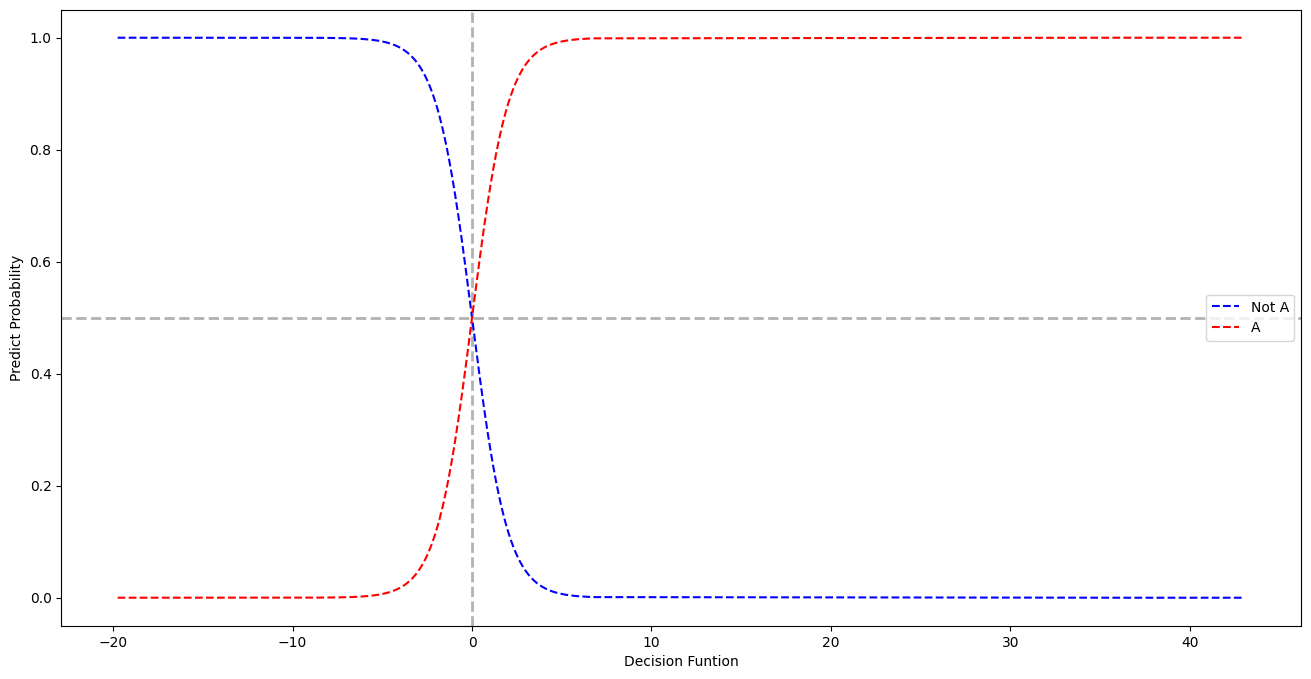

In [39]:
# 그래프로 만들었을 때 보기 편하도록 정렬
df2.sort_values('decision_function', inplace = True)
df2.reset_index(drop = True, inplace = True)

# 시각화
plt.figure(figsize = (16, 8))
plt.axhline(y = 0.5, linestyle = '--', linewidth = 2, color = 'black', alpha = 0.3)
plt.axvline(x = 0, linestyle = '--', linewidth = 2, color = 'black', alpha = 0.3)
plt.plot(df2['decision_function'], df2['predict proba of Not A'], '--', label = 'Not A', color = "#0400ff")
plt.plot(df2['decision_function'], df2['predict proba of A'], '--', label = 'A', color = "#ff0000")
plt.xlabel('Decision Funtion')
plt.ylabel('Predict Probability')
plt.legend()
plt.show()

- 혼동 행렬
    - 이진 분류의 예측 오류가 얼마인가, 어떠한 유형의 오류가 발생하는가를 나타내는 지표
    - **(예측, 실제)**
        - TN: True Negative, **(N, N)**
        - FP: False Positive, **(P, N)**
        - FN: False Negative, **(N, P)**
        - TP: True Positive, **(P, P)**
    
    - `accuracy` (정확도)
        - 실제 데이터와 예측 데이터가 얼마나 같은가?
            - TN + TP / TN + FP + FN + TP
    
    - `precision` (정밀도)
        - **예측이 Positive**인 것 중 **실제가 Positive**
        - TP / TP + FP
        - 스팸 메일인지 아닌지
    
    - `recall` (재현율)
        - **실제 Positive**인 것 중 **예측이 Positive**
        - TP / TP + FN
        - 암 환자 진단, 신용카드 사기 탐지
    
    - `f1 score`
        - 정밀도와 재현율의 조화평균으로 도출한 분류 성능 지표
        - 어느 한쪽에 치우치지 않고 적절하게 조화를 이루었을 때 높은 수치를 띔
        - 2 * ( (Precision * Recall) / (Precision + Recall) )

In [40]:
pred = logR.predict(X_test)

In [42]:
cm = confusion_matrix(y_test, pred)
acc = accuracy_score(y_test, pred)
prc = precision_score(y_test, pred)
rcll = recall_score(y_test, pred)
f1 = f1_score(y_test, pred)

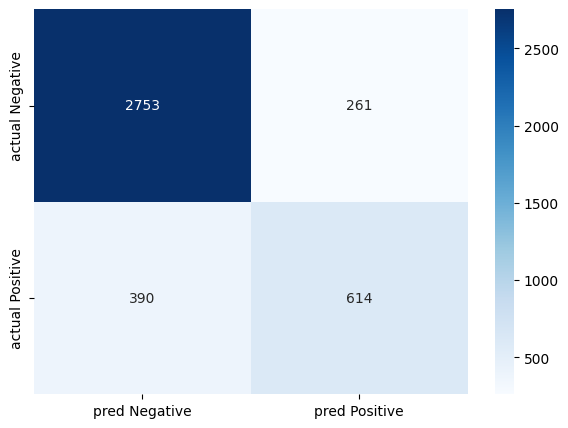

In [46]:
# 혼동 행렬 시각화

plt.figure(figsize = (7, 5))

sns.heatmap(
    cm, annot = True, cmap = 'Blues', fmt = 'd',
    xticklabels = ['pred Negative', 'pred Positive'],
    yticklabels = ['actual Negative', 'actual Positive']
)

plt.show()

In [47]:
print('정확도: ', round(acc, 2))
print('정밀도: ', round(prc, 2))
print('재현율: ', round(rcll, 2))
print('f1 score: ', round(f1, 2))

정확도:  0.84
정밀도:  0.7
재현율:  0.61
f1 score:  0.65


In [48]:
# 데이터의 불균형을 해결해보자
# 샘플링 기법을 이용하여 데이터의 균형을 맞춘다.
# 모델 생성 시 불균형한 데이터들에 가중치를 특별 부여

logR2 = LogisticRegression(class_weight='balanced')

In [49]:
logR2.fit(X_train, y_train)
pred_2 = logR2.predict(X_test)

In [50]:
acc = accuracy_score(y_test, pred_2)
prc = precision_score(y_test, pred_2)
rcll = recall_score(y_test, pred_2)
f1 = f1_score(y_test, pred_2)

print('정확도: ', round(acc, 2))
print('정밀도: ', round(prc, 2))
print('재현율: ', round(rcll, 2))
print('f1 score: ', round(f1, 2))

정확도:  0.82
정밀도:  0.59
재현율:  0.84
f1 score:  0.69


In [51]:
# 5월 7일 outlier_iqr2 함수를 가져와서 outlier.py 파일에 저장
# 모듈화 진행 후 작업

from outlier import outlier_iqr

In [ ]:
outlier_drop_df, outlier_dict = outlier_iqr(df, *df.drop('class_1', axis=1).columns, drop = True)

In [53]:
print(len(body), len(outlier_drop_df))

13393 12634


In [54]:
X_train, X_test, y_train, y_test = train_test_split(
    outlier_drop_df.drop(['class', 'class_1'], axis=1),
    outlier_drop_df['class_1'],
    test_size = 0.3,
    stratify = outlier_drop_df['class_1']
)

In [55]:
logR2.fit(X_train, y_train)
pred_3 = logR2.predict(X_test)

acc = accuracy_score(y_test, pred_3)
prc = precision_score(y_test, pred_3)
rcll = recall_score(y_test, pred_3)
f1 = f1_score(y_test, pred_3)

print('정확도: ', round(acc, 2))
print('정밀도: ', round(prc, 2))
print('재현율: ', round(rcll, 2))
print('f1 score: ', round(f1, 2))

정확도:  0.82
정밀도:  0.61
재현율:  0.85
f1 score:  0.71


In [56]:
# 샘플링: class_weight는 제외

# 언더 샘플링, SMOTE 사용
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import SMOTE

In [58]:
undersample = RandomUnderSampler(sampling_strategy = 1)
    # 소수 클래스와 다수 클래스의 숫자를 똑같이 맞춤: 약 6700개의 데이터를 날림

X = df.drop(['class', 'class_1'], axis = 1)
y = df['class_1']

X_under, y_under = undersample.fit_resample(X, y)

In [59]:
len(X_under)

6696

In [92]:
def logR_function(x, y, weight = None):
    X_train, X_test, y_train, y_test = train_test_split(
        x, y, test_size = 0.3, random_state = 42, stratify = y
    )

    model = LogisticRegression(class_weight = weight)

    model.fit(X_train, y_train)

    pred = model.predict(X_test)

    acc = accuracy_score(y_test, pred)
    prc = precision_score(y_test, pred, average = 'macro')
    rcll = recall_score(y_test, pred, average = 'macro')
    f1 = f1_score(y_test, pred, average = 'macro')

    print('정확도: ', round(acc, 2))
    print('정밀도: ', round(prc, 2))
    print('재현율: ', round(rcll, 2))
    print('f1 score: ', round(f1, 2))
    return pred, y_test

In [ ]:
under_pred, y_test = logR_function(X_under, y_under)

정확도:  0.83
정밀도:  0.82
재현율:  0.86
f1 score:  0.84


In [ ]:
smote, y_test = SMOTE(sampling_strategy=1)

X_over, y_over = smote.fit_resample(X, y)

over_pred, y_test = logR_function(X_over, y_over)

정확도:  0.85
정밀도:  0.82
재현율:  0.88
f1 score:  0.85


### 연습 문제

- body 데이터에서 성별 column을 0, 1로 변환
- class 컬럼의 데이터: A는 1, B는 2, C는 3, D는 4로 변경
- 극단치 데이터를 경계값들로 대체
- 로지스틱 회귀를 이용하여 혼동행렬, 나머지 성능 지표를 확인

In [63]:
body.head()

,age,gender,height_cm,weight_kg,body fat_%,diastolic,systolic,gripForce,sit and bend forward_cm,sit-ups counts,broad jump_cm,class
0,27.0,M,172.3,75.24,21.3,80.0,130.0,54.9,18.4,60.0,217.0,C
1,25.0,M,165.0,55.80,15.7,77.0,126.0,36.4,16.3,53.0,229.0,A
2,31.0,M,179.6,78.00,20.1,92.0,152.0,44.8,12.0,49.0,181.0,C
3,32.0,M,174.5,71.10,18.4,76.0,147.0,41.4,15.2,53.0,219.0,B
4,28.0,M,173.8,67.70,17.1,70.0,127.0,43.5,27.1,45.0,217.0,B


In [73]:
body = pd.read_csv('../data/bodyPerformance.csv')
body['gender'] = body['gender'].map(lambda x : 0 if x == 'M' else 1)

In [ ]:
body['class'] = body['class'].map( {'A': 1, 'B': 2, 'C': 3, 'D': 4} )

In [76]:
body.head()

,age,gender,height_cm,weight_kg,body fat_%,diastolic,systolic,gripForce,sit and bend forward_cm,sit-ups counts,broad jump_cm,class
0,27.0,0,172.3,75.24,21.3,80.0,130.0,54.9,18.4,60.0,217.0,3
1,25.0,0,165.0,55.80,15.7,77.0,126.0,36.4,16.3,53.0,229.0,1
2,31.0,0,179.6,78.00,20.1,92.0,152.0,44.8,12.0,49.0,181.0,3
3,32.0,0,174.5,71.10,18.4,76.0,147.0,41.4,15.2,53.0,219.0,2
4,28.0,0,173.8,67.70,17.1,70.0,127.0,43.5,27.1,45.0,217.0,2


In [98]:
outlier_replace_df, outlier_dict2 = outlier_iqr(body, *body.drop('class', axis=1).columns)


                지정된 컬럼의 이름: age,
                상단 경계: 82.5,
                하단 경계 -9.5
상단 경계를 벗어나는 데이터의 개수: 0, 하단 경계를 벗어나는 데이터의 개수: 0

                지정된 컬럼의 이름: gender,
                상단 경계: 2.5,
                하단 경계 -1.5
상단 경계를 벗어나는 데이터의 개수: 0, 하단 경계를 벗어나는 데이터의 개수: 0
Error: Invalid value '2.5' for dtype 'int64'

                지정된 컬럼의 이름: height_cm,
                상단 경계: 193.40000000000003,
                하단 경계 143.8
상단 경계를 벗어나는 데이터의 개수: 1, 하단 경계를 벗어나는 데이터의 개수: 9

                지정된 컬럼의 이름: weight_kg,
                상단 경계: 100.94999999999999,
                하단 경계 32.55000000000001
상단 경계를 벗어나는 데이터의 개수: 81, 하단 경계를 벗어나는 데이터의 개수: 2

                지정된 컬럼의 이름: body fat_%,
                상단 경계: 43.0,
                하단 경계 3.0
상단 경계를 벗어나는 데이터의 개수: 77, 하단 경계를 벗어나는 데이터의 개수: 0

                지정된 컬럼의 이름: diastolic,
                상단 경계: 108.5,
                하단 경계 48.5
상단 경계를 벗어나는 데이터의 개수: 17, 하단 경계를 벗어나는 데이터의 개수: 37

                지정된 컬럼의 이름: systolic,
                상단 경계

In [99]:
outlier_replace_df

,age,gender,height_cm,weight_kg,body fat_%,diastolic,systolic,gripForce,sit and bend forward_cm,sit-ups counts,broad jump_cm,class
0,27.0,0,172.3,75.24,21.3,80.0,130.0,54.9,18.4,60.0,217.0,3
1,25.0,0,165.0,55.80,15.7,77.0,126.0,36.4,16.3,53.0,229.0,1
2,31.0,0,179.6,78.00,20.1,92.0,152.0,44.8,12.0,49.0,181.0,3
3,32.0,0,174.5,71.10,18.4,76.0,147.0,41.4,15.2,53.0,219.0,2
4,28.0,0,173.8,67.70,17.1,70.0,127.0,43.5,27.1,45.0,217.0,2
...,...,...,...,...,...,...,...,...,...,...,...,...
13388,25.0,0,172.1,71.80,16.2,74.0,141.0,35.8,17.4,47.0,198.0,3
13389,21.0,0,179.7,63.90,12.1,74.0,128.0,33.0,1.1,48.0,167.0,4
13390,39.0,0,177.2,80.50,20.1,78.0,132.0,63.5,16.4,45.0,229.0,1
13391,64.0,1,146.1,57.70,40.4,68.0,121.0,19.3,9.2,0.0,75.0,4


In [101]:
X = outlier_replace_df.drop(['class'], axis = 1)
y = outlier_replace_df['class']

pred, y_test = logR_function(X, y)
cm = confusion_matrix(y_test, pred)
print()
print(confusion_matrix(y_test, pred))

정확도:  0.6
정밀도:  0.6
재현율:  0.6
f1 score:  0.6

[[739 239  26   0]
 [266 415 284  39]
 [120 192 492 201]
 [ 27  45 162 771]]


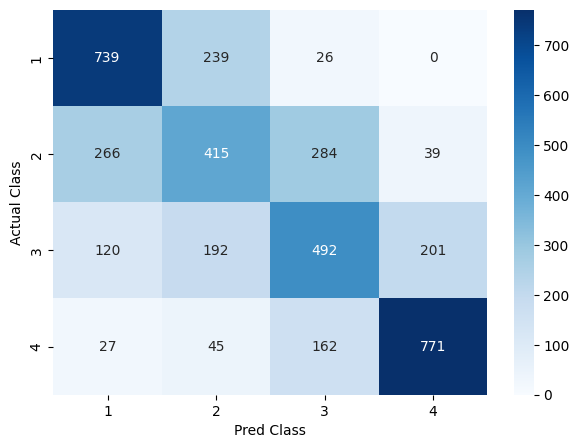

In [103]:
plt.figure(figsize=(7,5))

sns.heatmap(cm, annot=True, cmap='Blues', fmt='d', xticklabels=[1,2,3,4], yticklabels=[1,2,3,4])
plt.ylabel('Actual Class')
plt.xlabel('Pred Class')
plt.show()

- 정밀도, 재현율, f1-score는 다중 분류 모델에서 일반적으로 계산되지 않고 에러 발생

    - average

        - `macro`
            - 다중 분류에서 점수들의 평균을 출력
            - ex) a=90, b=30, c=50, d=10 → 45 출력
            - 모든 클래스의 점수를 차별없이 맞히는 모델
        - `micro`
            - 혼동 행렬의 모든 값들을 합산해서 점수를 생성
            - 이진 분류에서는 정확도와 같은 값이 생성
        - `weighted`
            - 각 클래스별 가중치(비율)를 생성하여 계산
            - a : 100/150, 90점 / b : 30/150, 30점 / c : 20/150, 20점
                - (90×100÷150) + (30×30÷150) + (20×20÷150)